In [2]:
from natural_pdf import PDF

pdf = PDF("../../pdfs/Atlanta_Public_Schools_GA_sample.pdf")
page = pdf.pages[0]

In [31]:
region = page.region(0, 170.5, 612, 287.49).above(until='text')
print(region.bbox)
print(region.above(until='text').bbox)

(0, 170.49, 612, 267.004)
(0, 170.48000000000002, 612, 244.5)


In [ ]:
from natural_pdf import PDF

pdf = PDF("pdfs/Atlanta_Public_Schools_GA_sample.pdf")
page = pdf.pages[0]
region = page.region(0, 170.5, 612, 287.49).above(until='text')
print(region.bbox)
print(region.above(until='text').bbox)


In [ ]:
page.region(0, 170.5, 612, 287.49).above(until='text')

In [3]:
pdf.add_exclusion(lambda page: page.find('line[width>=2]').above())
pdf.add_exclusion(lambda page: page.find_all('line')[-1].below())

<PDF source='../../pdfs/Atlanta_Public_Schools_GA_sample.pdf' pages=5>

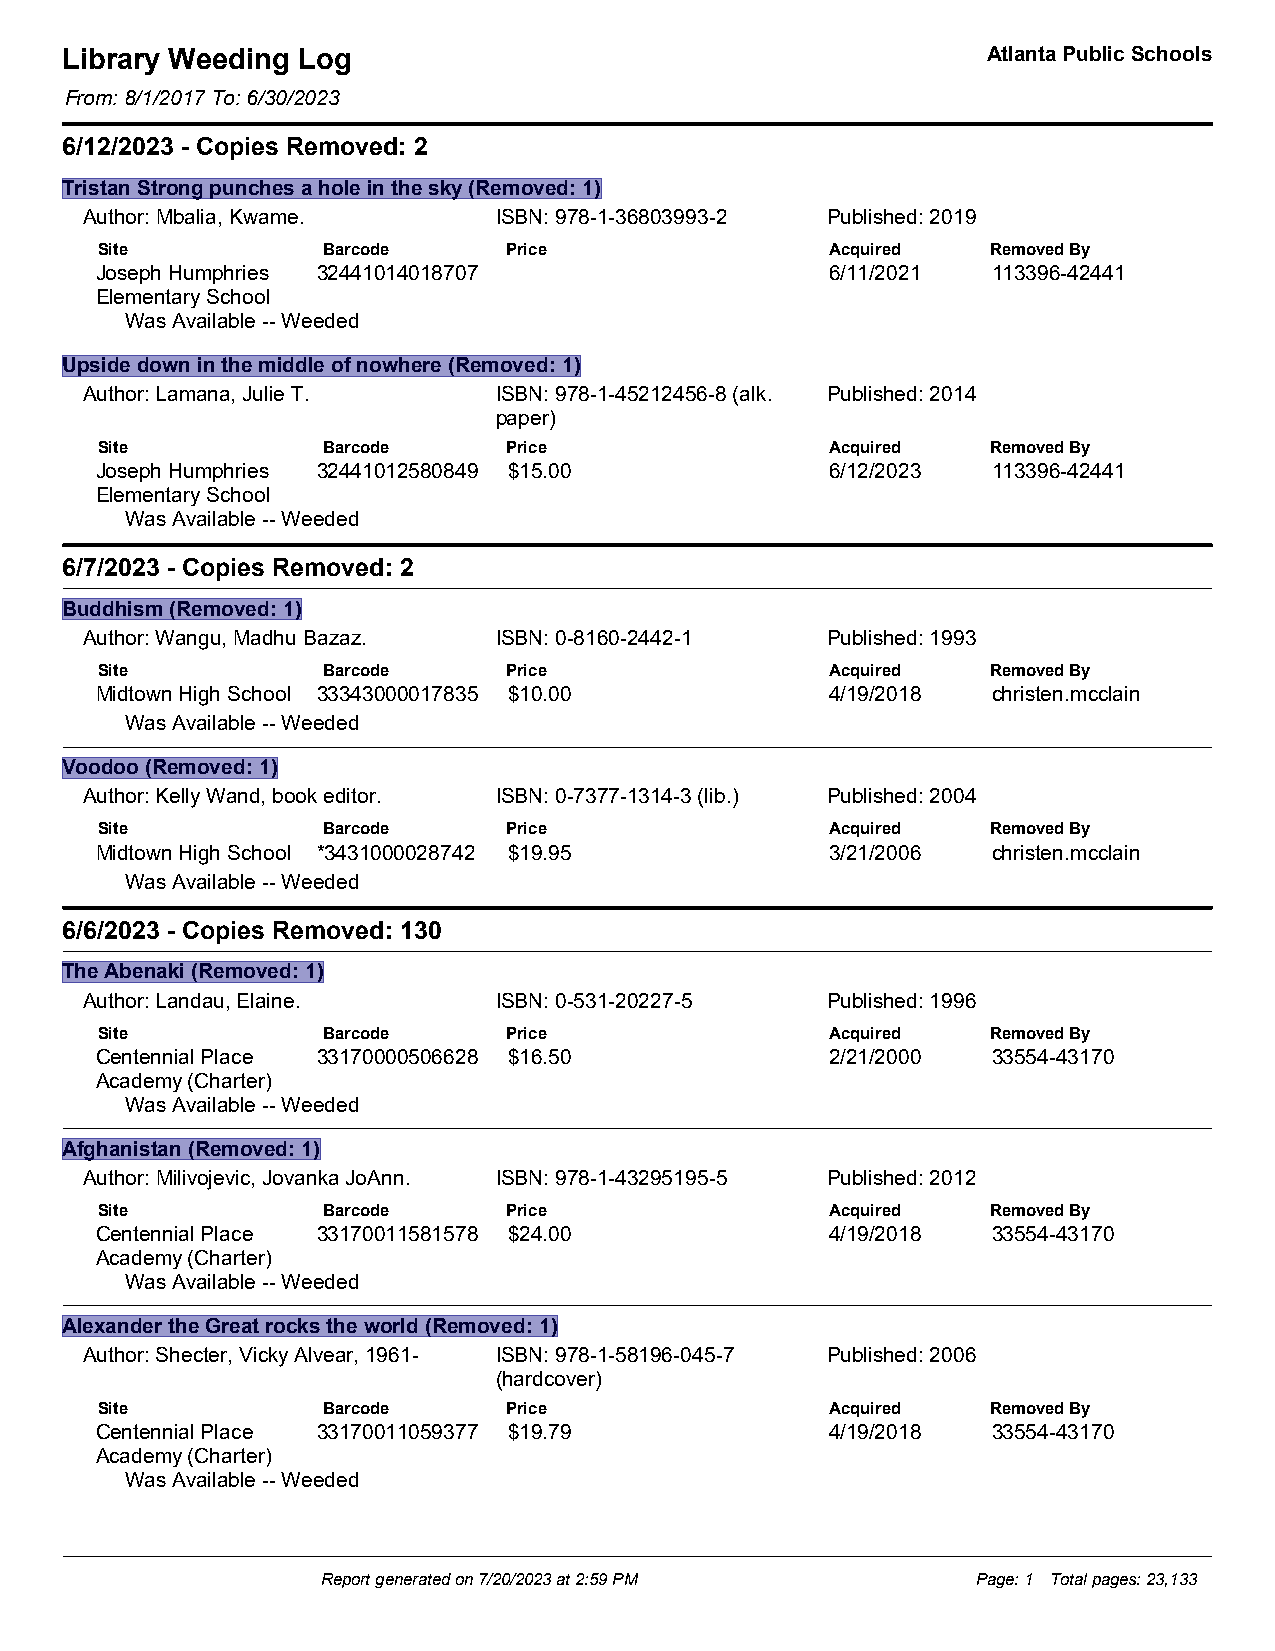

In [4]:
titles = page.find_all('text[font_variant=AAAAAB][size=10]')
titles.show()

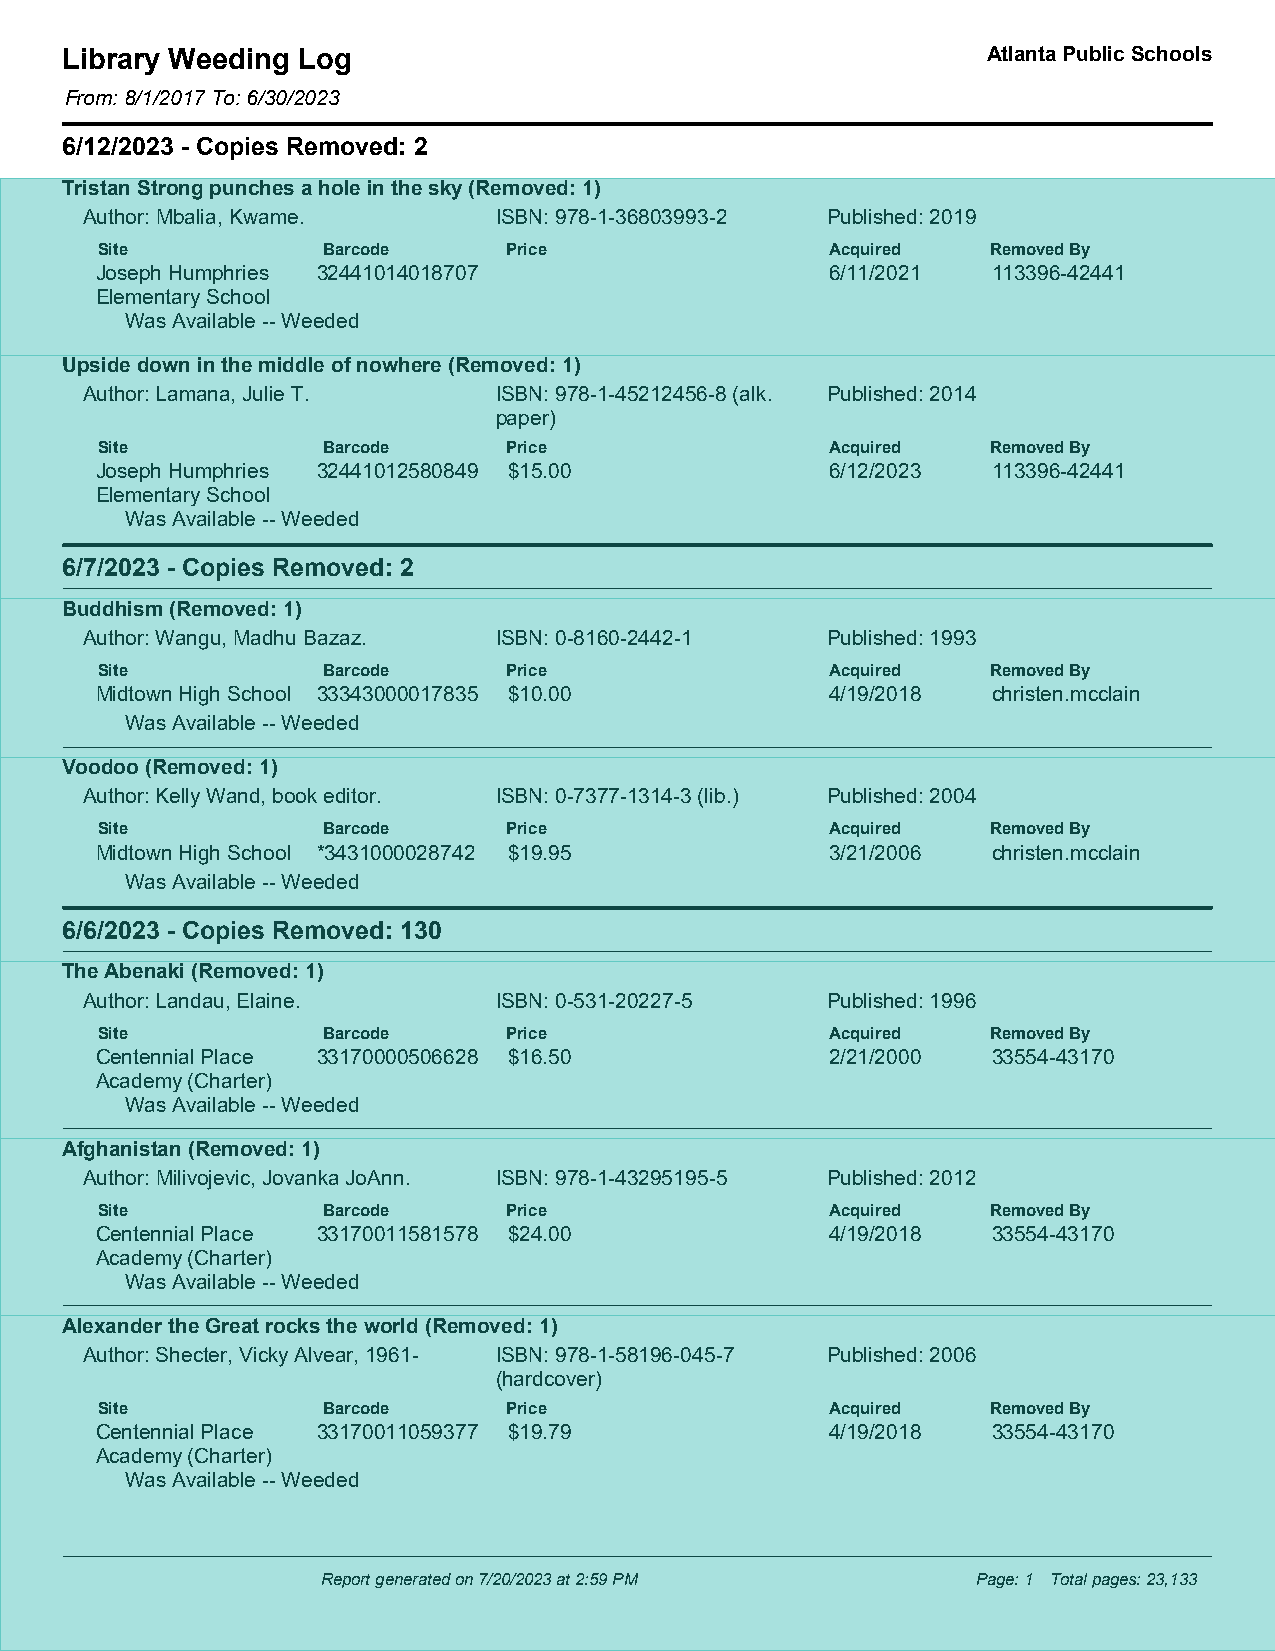

In [5]:
books = titles.below(until='text[font_variant=AAAAAB][size=10]',
                     include_endpoint=False,
                     include_source=True)
books.show()

In [6]:
len(books)

7

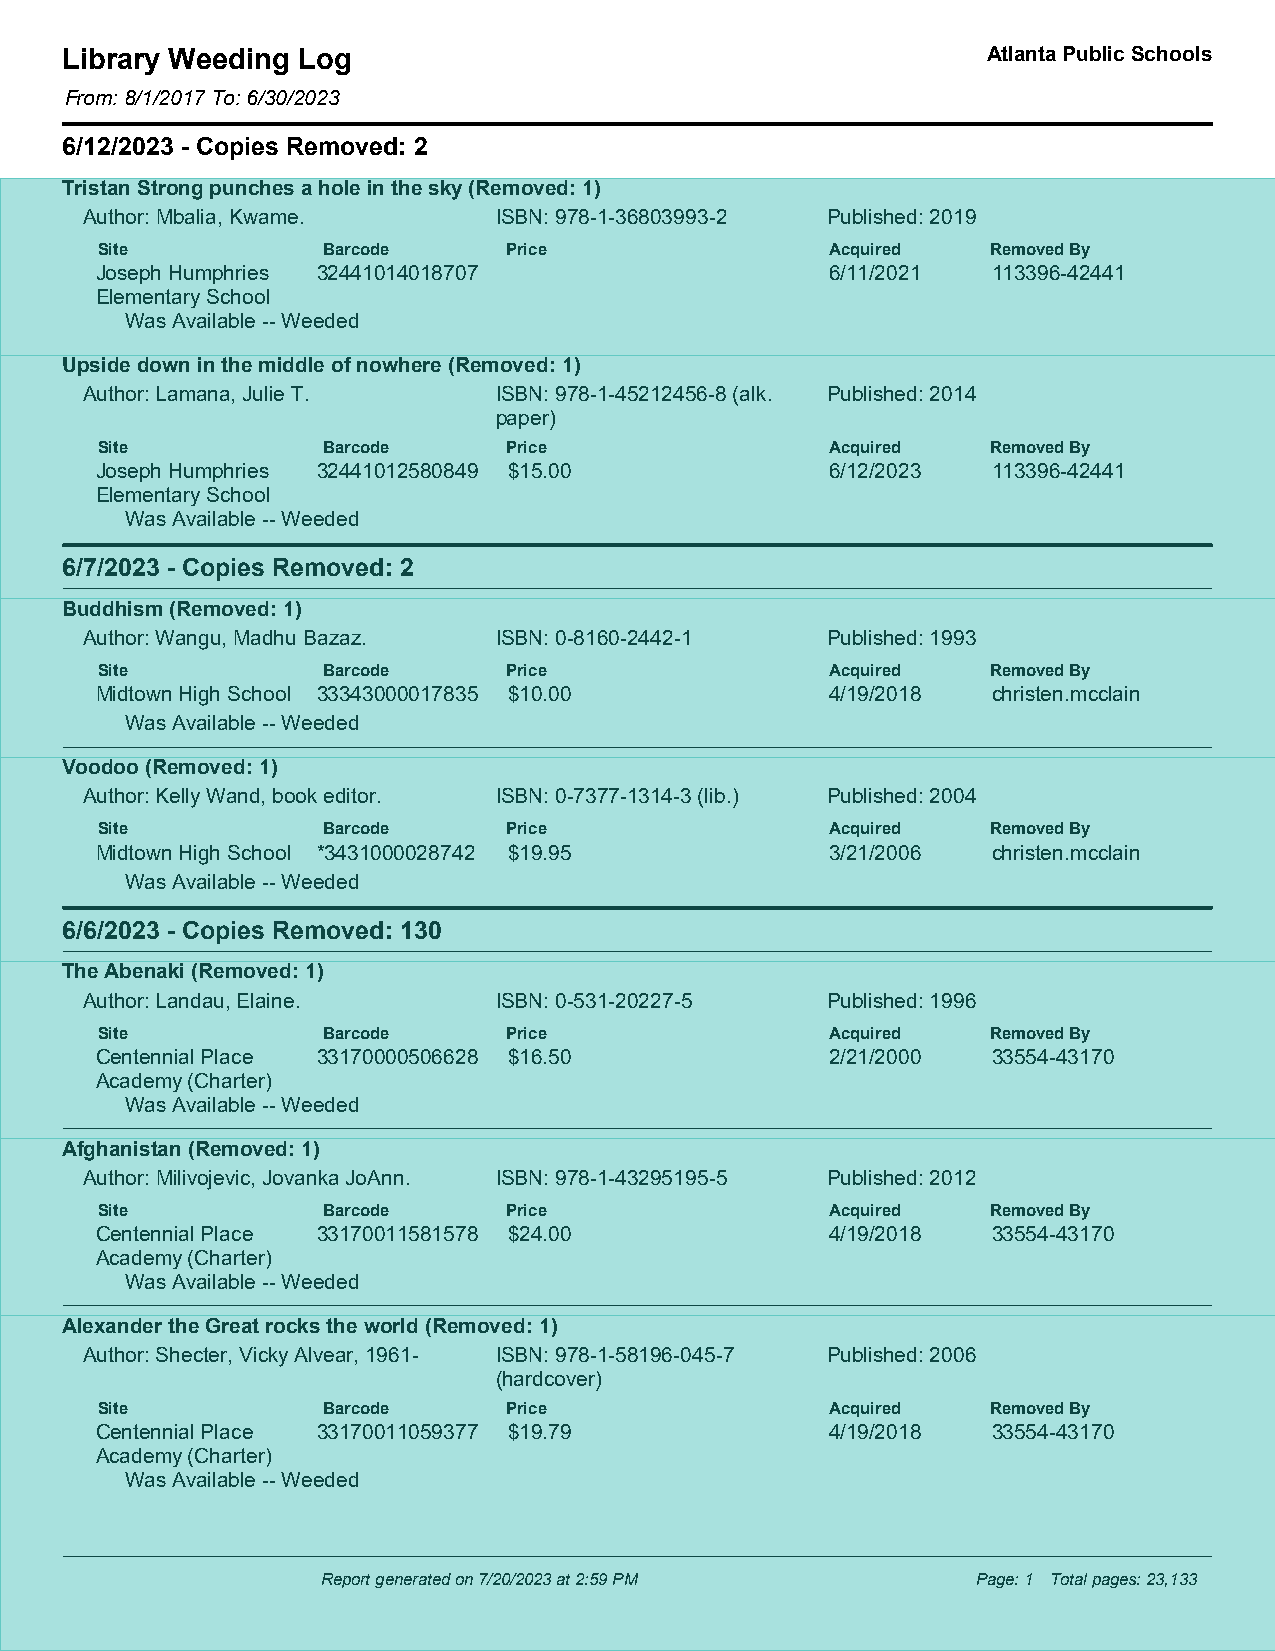

In [7]:
books.show()

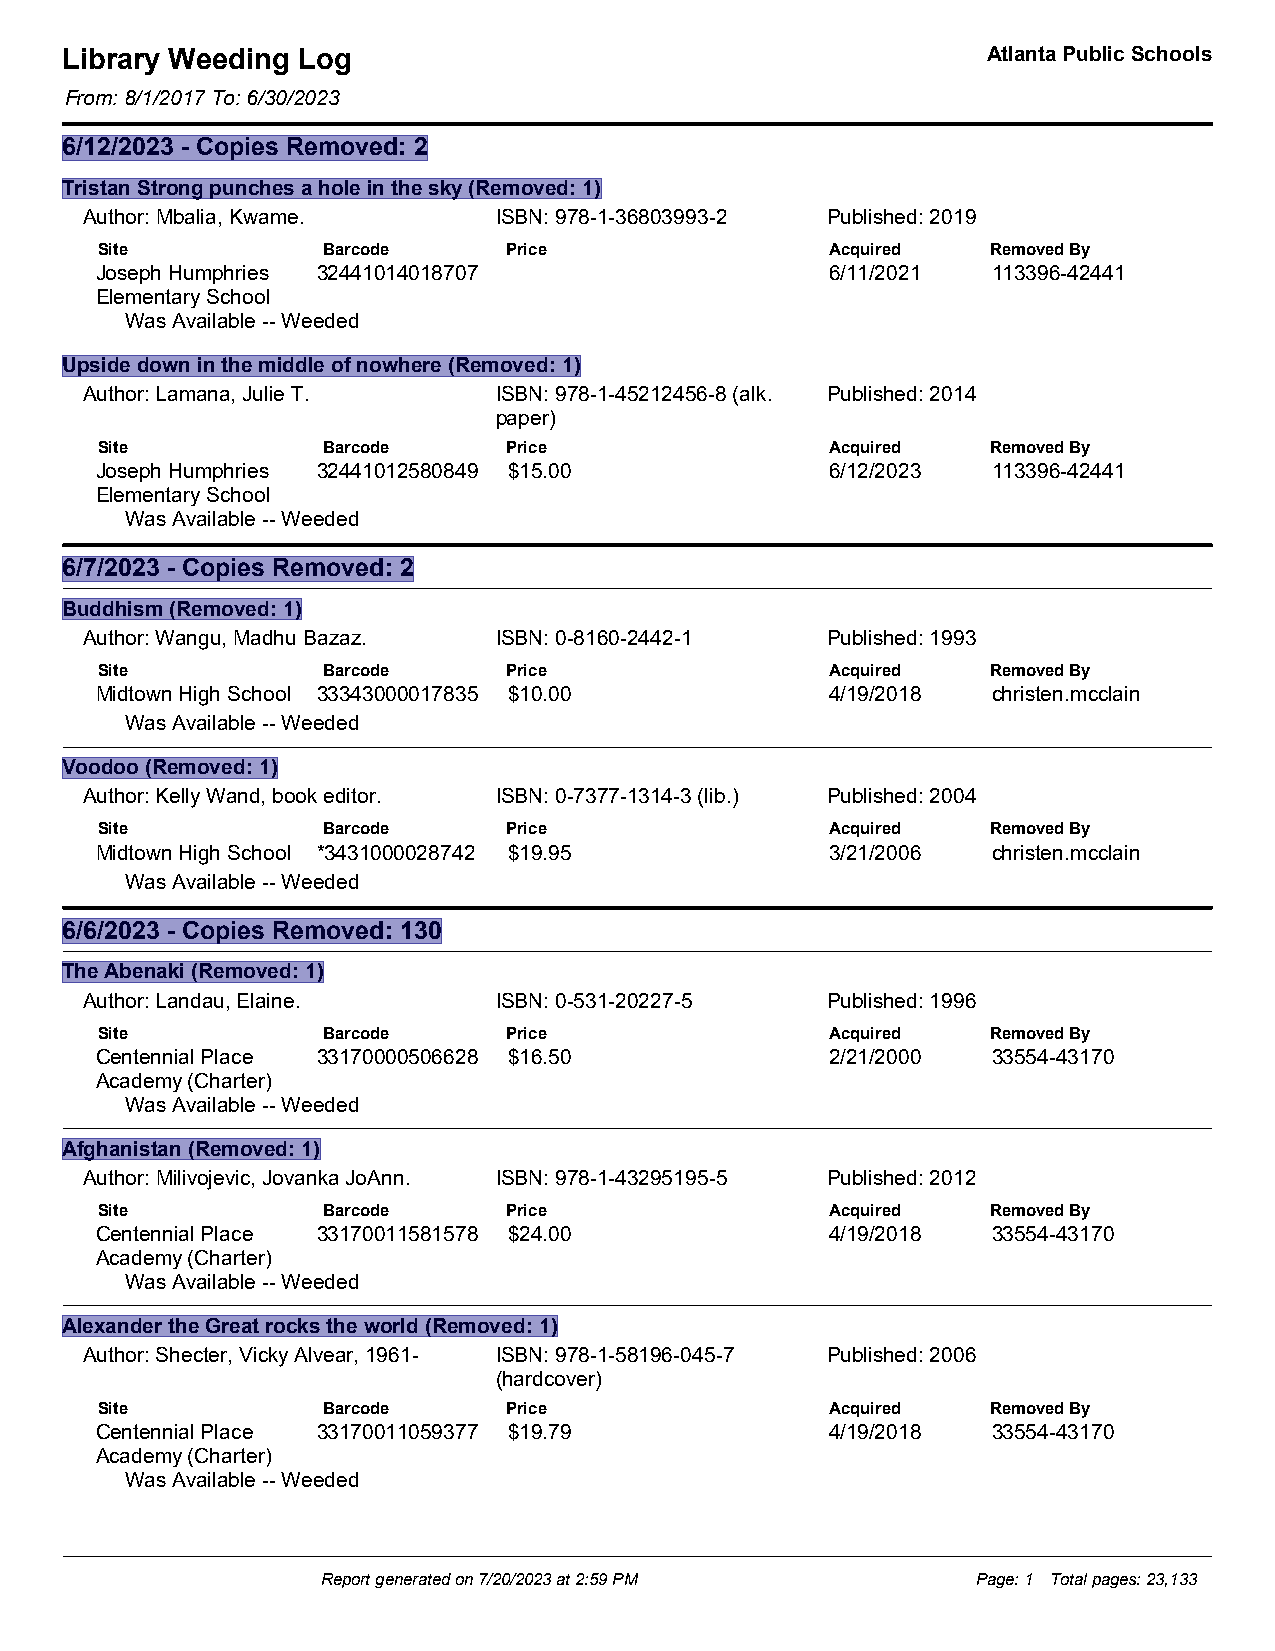

In [8]:
page.find_all("text:contains(Removed:)").show()

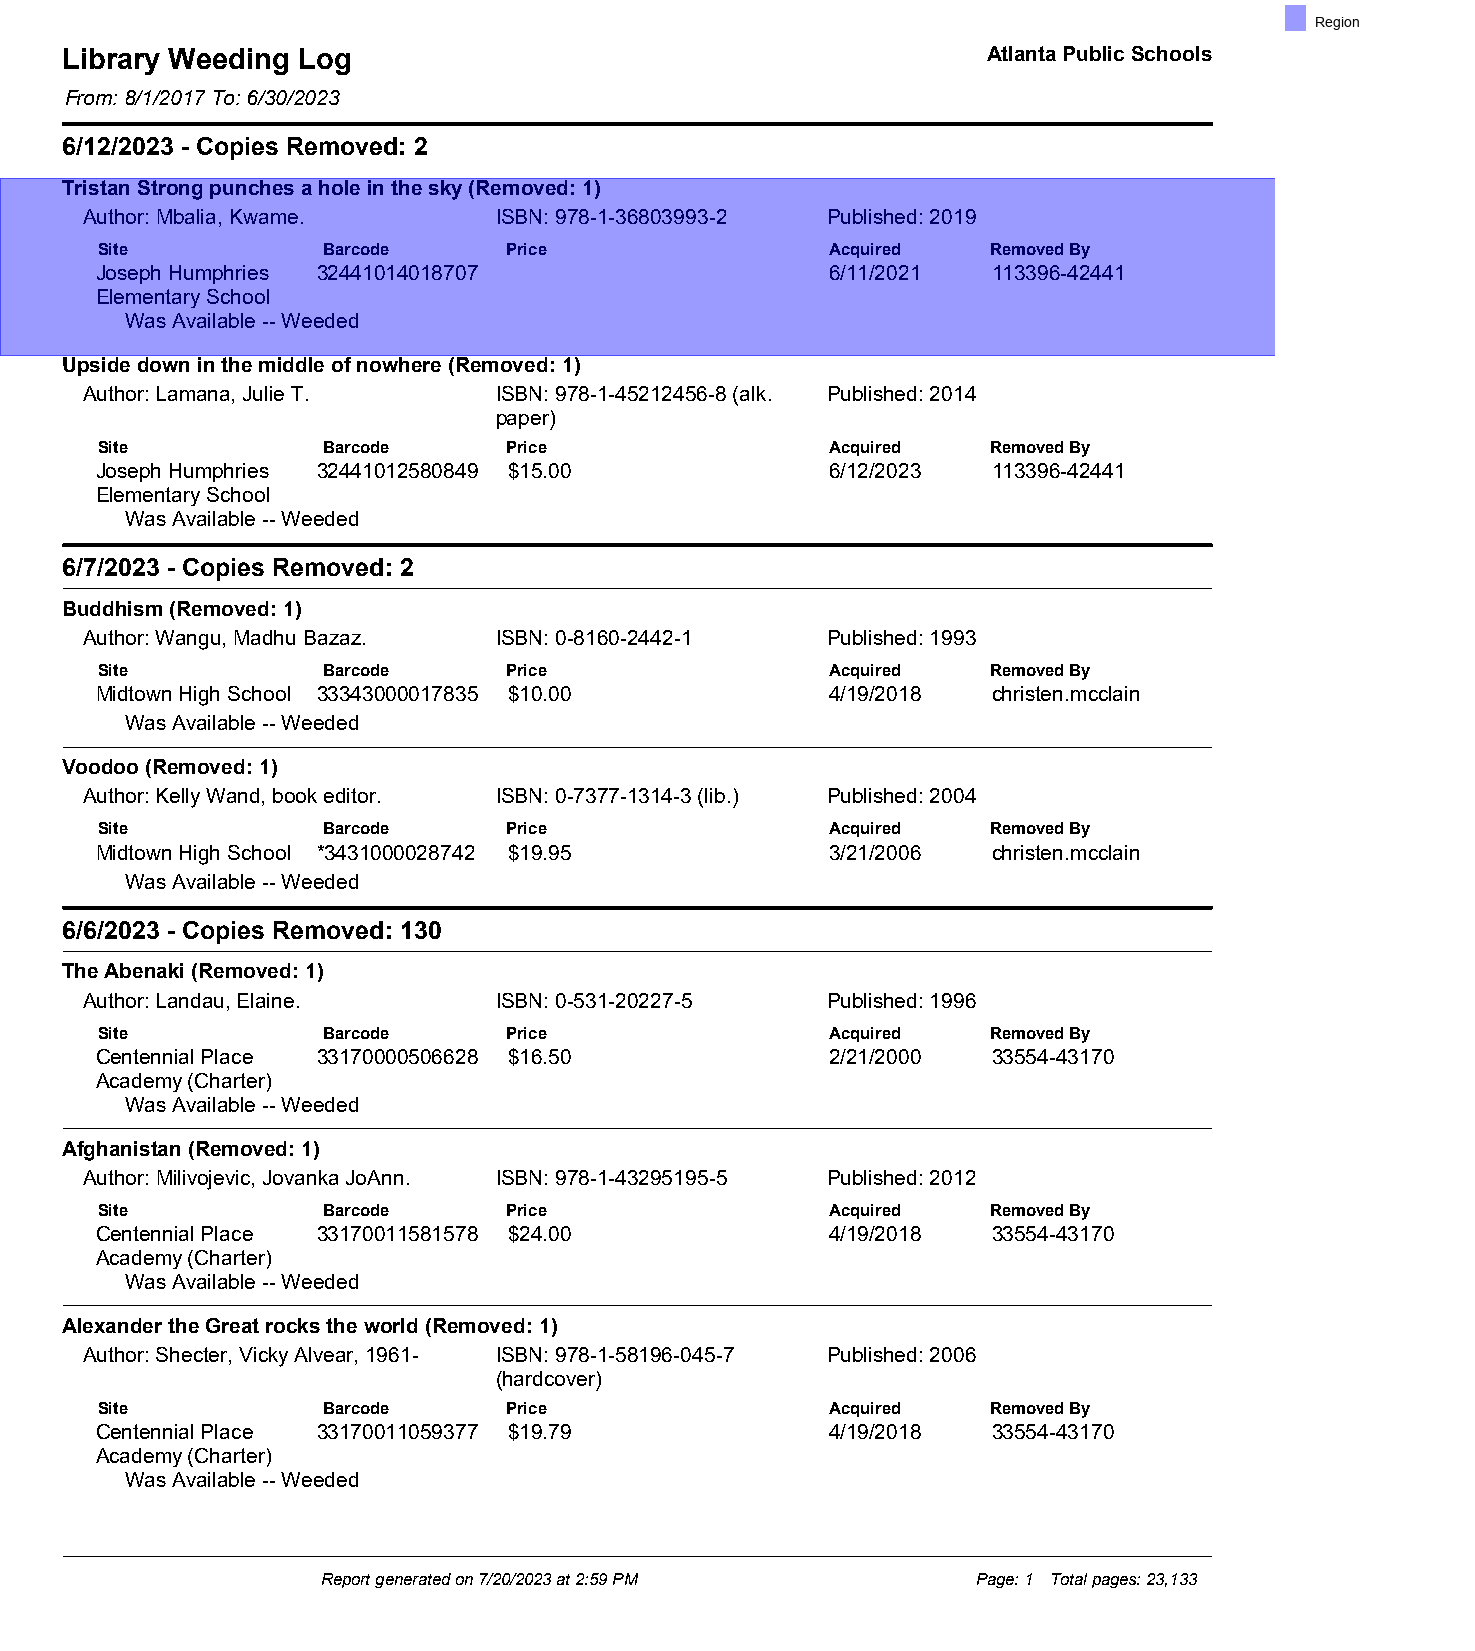

In [9]:
books[0].show()

In [10]:
titles.extract_each_text()

['Tristan Strong punches a hole in the sky (Removed: 1)',
 'Upside down in the middle of nowhere (Removed: 1)',
 'Buddhism (Removed: 1)',
 'Voodoo (Removed: 1)',
 'The Abenaki (Removed: 1)',
 'Afghanistan (Removed: 1)',
 'Alexander the Great rocks the world (Removed: 1)']

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'title': books.find('text[size=10]').extract_each_text(),
    'author': books.find('text:contains(Author)').extract_each_text(),
    'isbn': books.find('text:contains(ISBN)').below(until='text:contains(Price)', width='element', include_source=True, include_endpoint=False).extract_each_text(),
    'published': books.find('text:contains(Published)').extract_each_text(),
    'site': books.find('text:contains(Site)').below().clip(books).apply(lambda area: area.find_all('text[x0<47][size=10]').extract_text()),
    'barcode': books.find('text:contains(Barcode)').below(width='element', height=12).find('text', overlap='partial').extract_each_text(),
    'price': books.find('text:contains(Price)').below(width='element', height=12).expand(right=50).extract_each_text(),
    'acquired': books.find('text:contains(Acquired)').below(width='element', height=12).expand(right=10).extract_each_text(),
    'removed_by': books.find('text:contains(Removed By)').below(width='element', height=12).expand(right=40).extract_each_text(),
    'date': books.above(until='text[size>10]').endpoints.extract_each_text()
})
df['title'] = df['title'].str.replace("\(Removed.*", "", regex=True).str.strip()
df['author'] = df['author'].str.replace("Author:", "").str.strip()
df['isbn'] = df['isbn'].str.replace("ISBN:", "").str.replace("\n", " ").str.replace("\(.*\)", "", regex=True).str.strip()
df['published'] = df['published'].str.replace("Published:", "").str.strip()
df['date'] = df['date'].str.split(" - ").str[0]
df

,title,author,isbn,published,site,barcode,price,acquired,removed_by,date
0,Tristan Strong punches a hole in the sky,"Mbalia, Kwame.",978-1-36803993-2,2019,Joseph Humphries Elementary School,32441014018707,,6/11/2021,113396-42441,6/12/2023
1,Upside down in the middle of nowhere,"Lamana, Julie T.",978-1-45212456-8,2014,Joseph Humphries Elementary School,32441012580849,$15.00,6/12/2023,113396-42441,6/7/2023
2,Buddhism,"Wangu, Madhu Bazaz.",0-8160-2442-1,1993,Midtown High School,33343000017835,$10.00,4/19/2018,christen.mcclain,6/7/2023
3,Voodoo,"Kelly Wand, book editor.",0-7377-1314-3,2004,Midtown High School,*3431000028742,$19.95,3/21/2006,christen.mcclain,6/6/2023
4,The Abenaki,"Landau, Elaine.",0-531-20227-5,1996,Centennial Place Academy (Charter),33170000506628,$16.50,2/21/2000,33554-43170,6/6/2023
5,Afghanistan,"Milivojevic, Jovanka JoAnn.",978-1-43295195-5,2012,Centennial Place Academy (Charter),33170011581578,$24.00,4/19/2018,33554-43170,6/6/2023
6,Alexander the Great rocks the world,"Shecter, Vicky Alvear, 1961-",978-1-58196-045-7,2006,Centennial Place Academy (Charter),33170011059377,$19.79,4/19/2018,33554-43170,6/6/2023


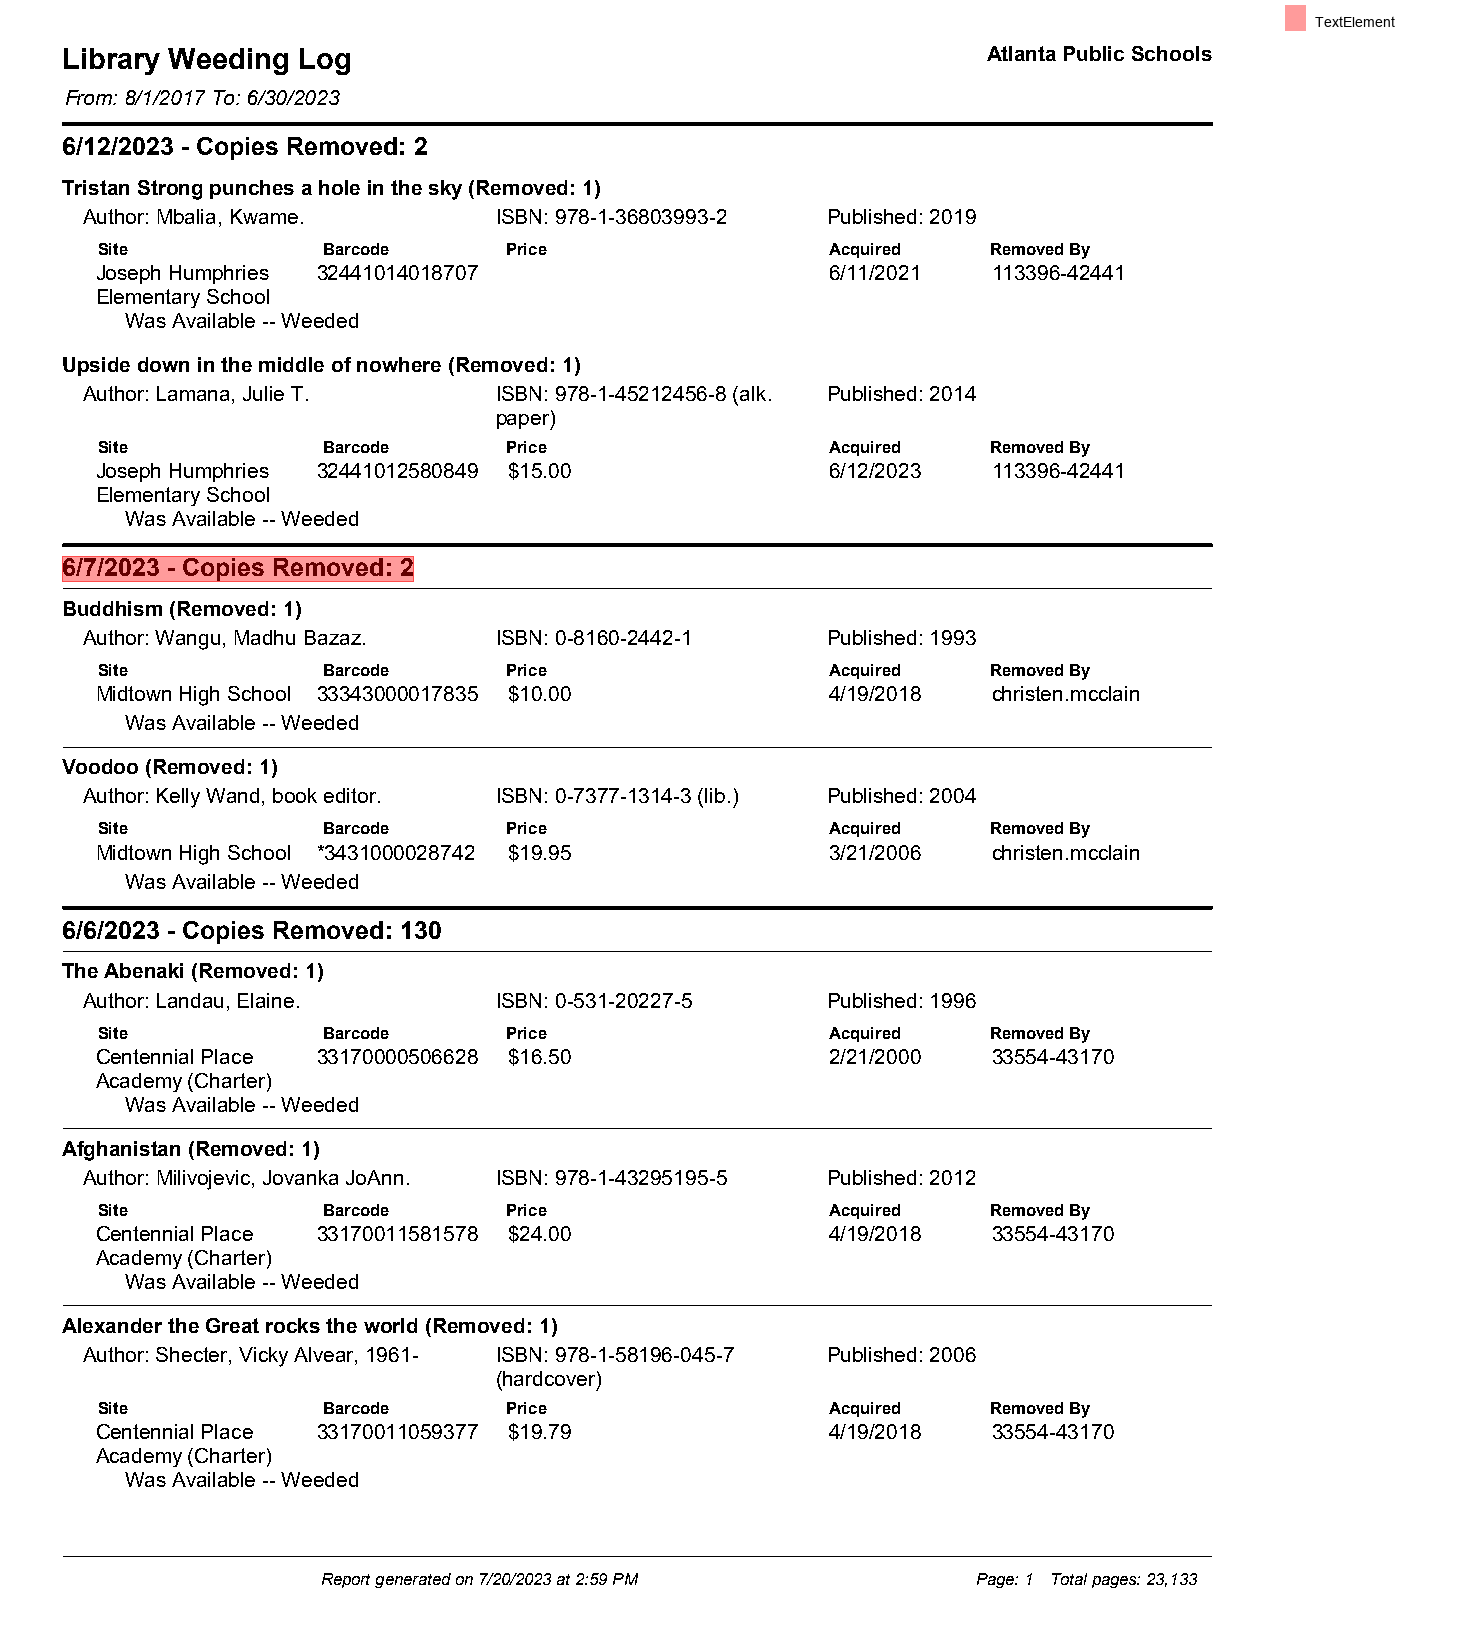

In [14]:
books[1].above(until='text[size>10]').endpoint.show()

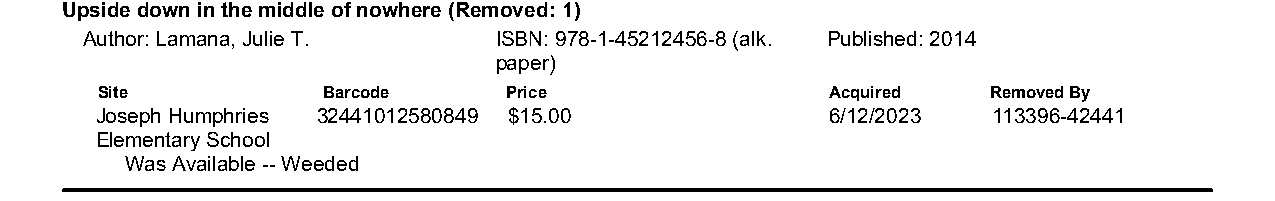

In [ ]:
books[0].show()

In [51]:
# for page in pdf.pages:
# Combine them all!